# 05 - Machine Learning Modeling

## Predicting Extreme Energy Demand One Hour Ahead

The feature-engineering stage created a modeling dataset using recent demand behavior, operating time and equipment information.

In this notebook, I compare a simple threshold baseline with Logistic Regression and Random Forest to predict extreme demand one hour ahead.

The models are evaluated on a later time period to represent how the system would perform on future operating conditions.

## 1. Load the Modeling Dataset

I load the feature-engineered dataset created in the previous notebook and check the distribution of the one-hour-ahead target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data_processed/ml_ready_energy_data.csv"
)

df["window_start_utc"] = pd.to_datetime(
    df["window_start_utc"]
)

print("Shape:", df.shape)

df["extreme_1h_ahead"].value_counts(normalize=True) * 100

Shape: (993411, 17)


extreme_1h_ahead
0    88.907814
1    11.092186
Name: proportion, dtype: float64

## 2. Chronological Train-Test Split

Because the observations are time-dependent, I use a chronological split rather than a random split.

Earlier observations are used for training and later observations for testing. A one-hour gap is left between the two periods because the prediction target looks one hour into the future.

In [2]:
split_time = pd.Timestamp("2025-11-08 20:15:00")

train_end = split_time - pd.Timedelta(hours=1)

train_df = df[
    df["window_start_utc"] < train_end
].copy()

test_df = df[
    df["window_start_utc"] >= split_time
].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

print(
    "Training period:",
    train_df["window_start_utc"].min(),
    "to",
    train_df["window_start_utc"].max()
)

print(
    "Test period:",
    test_df["window_start_utc"].min(),
    "to",
    test_df["window_start_utc"].max()
)

print("\nTrain target:")
print(
    train_df["extreme_1h_ahead"]
    .value_counts(normalize=True) * 100
)

print("\nTest target:")
print(
    test_df["extreme_1h_ahead"]
    .value_counts(normalize=True) * 100
)

Training rows: 807338
Test rows: 185929
Training period: 2024-12-31 08:30:00 to 2025-11-08 19:00:00
Test period: 2025-11-08 20:15:00 to 2025-12-31 22:45:00

Train target:
extreme_1h_ahead
0    89.970248
1    10.029752
Name: proportion, dtype: float64

Test target:
extreme_1h_ahead
0    84.287013
1    15.712987
Name: proportion, dtype: float64


**Finding:** Extreme-demand observations represent approximately 10.0% of the training period and 15.7% of the later test period. This difference shows some temporal variation and makes the later test period a useful evaluation of future operating conditions.

## 3. Prepare the Modeling Features

The models use current and historical demand, recent demand changes, rolling behavior, operating time and equipment type.

Individual asset IDs are excluded so that the models focus on general operating patterns rather than memorizing specific machines.

In [3]:
numeric_features = [
    "Demand_kW",
    "demand_15m_ago",
    "demand_30m_ago",
    "demand_45m_ago",
    "demand_60m_ago",
    "change_15m",
    "change_60m",
    "rolling_mean_1h",
    "rolling_std_1h",
    "demand_threshold_ratio",
    "hour",
    "day_of_week",
    "is_weekend"
]

categorical_features = [
    "asset_type"
]

target = "extreme_1h_ahead"

In [4]:
X_train = train_df[numeric_features + categorical_features]
X_test = test_df[numeric_features + categorical_features]

y_train = train_df[target]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (807338, 14)
X_test: (185929, 14)


## 4. Baseline Prediction

Before training machine-learning models, I create a simple persistence baseline.

The baseline predicts extreme demand one hour ahead when the asset is already operating above its extreme-demand threshold at the prediction time.

This provides a simple benchmark for determining whether machine learning adds useful early-warning information.

In [5]:
baseline_pred = (
    test_df["demand_threshold_ratio"] > 1
).astype(int)

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))

Accuracy: 0.9256167676908927
Precision: 0.7633786421063443
Recall: 0.7631696046551429
F1: 0.7632741090685016

Confusion Matrix:
[[149803   6911]
 [  6919  22296]]


**Baseline Result:** The threshold baseline achieved approximately 76.3% precision, 76.3% recall and an F1-score of 76.3%.

It identified many future extreme-demand observations, but missed 6,919 extreme observations in the test period. This provides a strong benchmark for evaluating whether machine learning can improve early-warning coverage.

## 5. Logistic Regression

Logistic Regression provides a simple machine-learning benchmark using recent demand behavior, operating time and equipment type.

Because extreme-demand observations are less common, class weighting is used to give greater importance to the minority class.

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [10]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

In [11]:
print(classification_report(
    y_test,
    logistic_pred,
    digits=3
))

print("ROC-AUC:",
      roc_auc_score(y_test, logistic_prob))

print("PR-AUC:",
      average_precision_score(y_test, logistic_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

              precision    recall  f1-score   support

           0      0.920     0.771     0.839    156714
           1      0.344     0.642     0.447     29215

    accuracy                          0.751    185929
   macro avg      0.632     0.707     0.643    185929
weighted avg      0.830     0.751     0.778    185929

ROC-AUC: 0.7199569155772516
PR-AUC: 0.4223595887341357

Confusion Matrix:
[[120897  35817]
 [ 10471  18744]]


**Result:** Logistic Regression achieved 34.4% precision, 64.2% recall and an F1-score of 44.7% for future extreme-demand observations, with a ROC-AUC of 0.720 and PR-AUC of 0.422.

It did not outperform the persistence baseline, suggesting that a simple linear decision boundary may not capture the relationships in the engineered features sufficiently well.

## 6. Random Forest

The Logistic Regression results suggest that the relationship between recent demand behavior and future extreme demand may not be purely linear.

I therefore test Random Forest, which can capture nonlinear relationships and interactions between the input features.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore"
        ), categorical_features)
    ]
)

In [13]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [14]:
print(classification_report(
    y_test,
    rf_pred,
    digits=3
))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, rf_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_test, rf_prob)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

              precision    recall  f1-score   support

           0      0.986     0.905     0.944    156714
           1      0.646     0.930     0.762     29215

    accuracy                          0.909    185929
   macro avg      0.816     0.917     0.853    185929
weighted avg      0.932     0.909     0.915    185929

ROC-AUC: 0.963616323316442
PR-AUC: 0.8111194996829347

Confusion Matrix:
[[141800  14914]
 [  2046  27169]]


**Random Forest Result:** Random Forest achieved a ROC-AUC of 0.964 and PR-AUC of 0.811 on the chronological test period.

At the default classification threshold, it detected approximately 93.0% of future extreme-demand observations, compared with 76.3% for the baseline. Missed extreme observations decreased from 6,919 to 2,046.

This improved recall comes with lower precision and more false-positive alerts, creating an operational trade-off that will be considered during model evaluation.

## 7. Early-Warning Value Beyond the Threshold Baseline

The threshold baseline works when an asset is already operating above its extreme-demand threshold.

To test whether machine learning provides earlier information, I examine future extreme-demand observations that the baseline missed and check how many Random Forest successfully identifies.

In [15]:
baseline_missed_mask = (
    (y_test.values == 1) &
    (baseline_pred.values == 0)
)

baseline_missed_count = baseline_missed_mask.sum()

rf_caught_baseline_missed = (
    rf_pred[baseline_missed_mask] == 1
).sum()

rf_recovery_rate = (
    rf_caught_baseline_missed /
    baseline_missed_count
)

print("Future extremes missed by baseline:", baseline_missed_count)
print("Caught by Random Forest:", rf_caught_baseline_missed)
print("Recovery rate:", round(rf_recovery_rate * 100, 2), "%")

Future extremes missed by baseline: 6919
Caught by Random Forest: 4927
Recovery rate: 71.21 %


**Early-Warning Result:** The baseline missed 6,919 future extreme-demand observations when equipment was not yet above its threshold.

Random Forest identified 4,927 of these observations, recovering approximately 71.2% of the cases missed by the baseline.

Because consecutive observations may belong to the same extreme-demand episode, episode-level performance is evaluated next.

## 8. Early Warning for New Extreme-Demand Episodes

Observation-level results can contain several consecutive observations from the same high-demand episode.

I therefore identify the start of each new extreme-demand episode and evaluate whether the models provided a warning one hour before it began.

Because the dataset contains a small number of timestamp gaps, episode starts are only considered valid when consecutive observations are exactly 15 minutes apart.

In [16]:
results = test_df[
    [
        "AssetId",
        "window_start_utc",
        "demand_threshold_ratio",
        "extreme_1h_ahead"
    ]
].copy()

results["rf_pred"] = rf_pred
results["rf_prob"] = rf_prob
results["baseline_pred"] = baseline_pred.values

In [17]:
results = results.sort_values(
    ["AssetId", "window_start_utc"]
).copy()

results["previous_future_state"] = (
    results.groupby("AssetId")["extreme_1h_ahead"]
    .shift(1)
)

results["previous_prediction_time"] = (
    results.groupby("AssetId")["window_start_utc"]
    .shift(1)
)

results["prediction_gap"] = (
    results["window_start_utc"] -
    results["previous_prediction_time"]
)

results["validated_new_episode"] = (
    (results["extreme_1h_ahead"] == 1) &
    (results["previous_future_state"] == 0) &
    (results["prediction_gap"] == pd.Timedelta(minutes=15))
)

In [18]:
validated_events = results[
    results["validated_new_episode"]
].copy()

rf_validated_recall = validated_events["rf_pred"].mean()
baseline_validated_recall = validated_events["baseline_pred"].mean()

print("Validated new extreme episodes:", len(validated_events))

print(
    "Random Forest recall:",
    round(rf_validated_recall * 100, 2),
    "%"
)

print(
    "Baseline recall:",
    round(baseline_validated_recall * 100, 2),
    "%"
)

Validated new extreme episodes: 5093
Random Forest recall: 82.82 %
Baseline recall: 51.29 %


**New-Episode Early-Warning Result:** The test period contained 5,093 validated new extreme-demand episode starts.

Random Forest detected approximately **82.8%** of these episodes one hour ahead, compared with approximately **51.29%** for the threshold baseline.

This represents an improvement of approximately **31.5 percentage points** in new-episode recall and provides the strongest evidence that the model adds useful early-warning capability.

## 9. Feature Importance

I examine Random Forest feature importance to understand which variables contribute most strongly to the one-hour-ahead predictions.

In [19]:
feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
9,num__demand_threshold_ratio,0.439837
8,num__rolling_std_1h,0.079532
0,num__Demand_kW,0.077238
7,num__rolling_mean_1h,0.060904
1,num__demand_15m_ago,0.047308
10,num__hour,0.040110
2,num__demand_30m_ago,0.035629
6,num__change_60m,0.033075
4,num__demand_60m_ago,0.032503
3,num__demand_45m_ago,0.031585


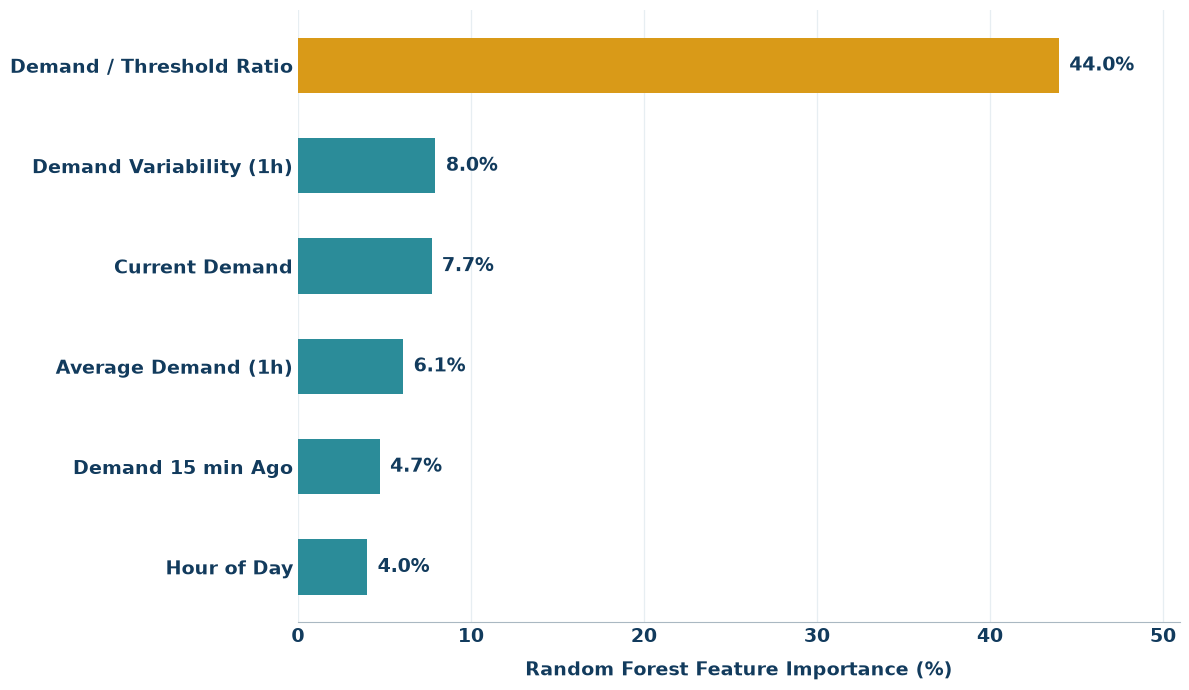

In [20]:
# =========================================================

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"
light_grey = "#E7EEF2"
axis_grey = "#AAB8C2"


# =========================================================
# TOP 6 FEATURES
# =========================================================

plot_importance = feature_importance.head(6).copy()

plot_importance["feature"] = (
    plot_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ")
    .replace({
        "demand threshold ratio": "Demand / Threshold Ratio",
        "rolling std 1h": "Demand Variability (1h)",
        "Demand kW": "Current Demand",
        "rolling mean 1h": "Average Demand (1h)",
        "demand 15m ago": "Demand 15 min Ago",
        "demand 30m ago": "Demand 30 min Ago",
        "demand 45m ago": "Demand 45 min Ago",
        "demand 60m ago": "Demand 60 min Ago",
        "change 60m": "Demand Change (60 min)",
        "hour": "Hour of Day"
    })
)

plot_importance = plot_importance.sort_values(
    "importance",
    ascending=True
)

plot_importance["importance_pct"] = (
    plot_importance["importance"] * 100
)


# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_alpha(0)
ax.set_facecolor("white")


# Gold for strongest feature, teal for others
colors = [
    gold if feature == "Demand / Threshold Ratio" else teal
    for feature in plot_importance["feature"]
]


bars = ax.barh(
    plot_importance["feature"],
    plot_importance["importance_pct"],
    color=colors,
    height=0.55
)


# =========================================================
# VALUE LABELS
# =========================================================

for bar in bars:

    value = bar.get_width()

    ax.text(
        value + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=14,
        fontweight="bold",
        color=navy
    )


# =========================================================
# AXES
# =========================================================

ax.set_xlabel(
    "Random Forest Feature Importance (%)",
    fontsize=14,
    fontweight="bold",
    color=navy,
    labelpad=10
)

ax.set_ylabel("")


ax.tick_params(
    axis="y",
    labelsize=14,
    length=0,
    colors=navy
)

ax.tick_params(
    axis="x",
    labelsize=14,
    length=0,
    colors=navy
)
# Make feature names bold

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")


# =========================================================
# GRID
# =========================================================

ax.grid(
    axis="x",
    color=light_grey,
    linewidth=0.9
)

ax.set_axisbelow(True)


# =========================================================
# CLEAN SPINES
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color(axis_grey)


# Give labels some space
ax.set_xlim(
    0,
    plot_importance["importance_pct"].max() + 7
)


plt.tight_layout()


# =========================================================
# SAVE FOR POWERPOINT
# =========================================================

plt.savefig(
    "../presentation/feature_importance_light.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

## 10. Model Comparison

I compare the baseline, Logistic Regression and Random Forest using precision, recall and F1-score.

Because the main objective is early warning, I also compare the ability of Random Forest and the baseline to identify new extreme-demand episode starts one hour ahead.

In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Threshold Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, logistic_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, logistic_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, logistic_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        np.nan,
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "PR_AUC": [
        np.nan,
        average_precision_score(y_test, logistic_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

comparison.round(3)

,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Threshold Baseline,0.763,0.763,0.763,NaN,NaN
1,Logistic Regression,0.344,0.642,0.447,0.720,0.422
2,Random Forest,0.646,0.930,0.762,0.964,0.811


In [22]:
episode_comparison = pd.DataFrame({
    "Method": [
        "Threshold Baseline",
        "Random Forest"
    ],
    "New_Episode_Recall": [
        baseline_validated_recall * 100,
        rf_validated_recall * 100
    ]
})

episode_comparison.round(2)

,Method,New_Episode_Recall
0,Threshold Baseline,51.29
1,Random Forest,82.82


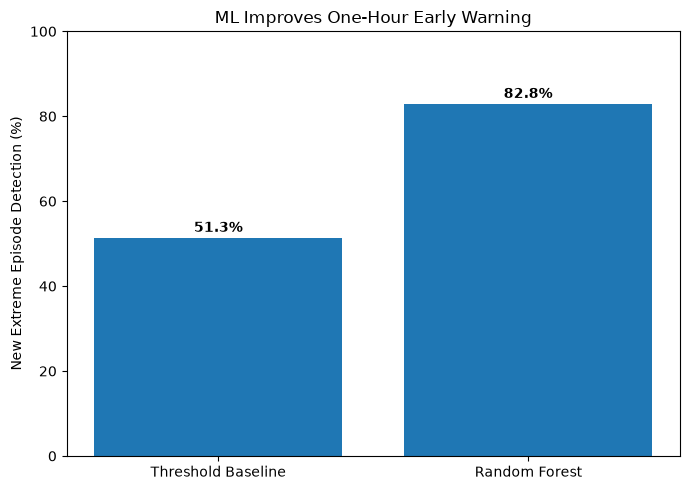

In [23]:
plt.figure(figsize=(7, 5))

plt.bar(
    episode_comparison["Method"],
    episode_comparison["New_Episode_Recall"]
)

plt.ylabel("New Extreme Episode Detection (%)")
plt.title("ML Improves One-Hour Early Warning")
plt.ylim(0, 100)

for i, value in enumerate(
    episode_comparison["New_Episode_Recall"]
):
    plt.text(
        i,
        value + 1.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**Model Comparison:** Random Forest provided the strongest overall predictive performance, with a ROC-AUC of 0.964, PR-AUC of 0.811 and approximately 93.0% recall for future extreme-demand observations.

The baseline achieved higher precision, while Random Forest provided substantially greater early-warning coverage.

For validated new extreme-demand episode starts, Random Forest achieved approximately **82.8% recall**, compared with **51.3% for the baseline**.

Random Forest is therefore selected as the primary model, with the trade-off that improved recall produces more false-positive alerts.

In [24]:
import joblib

joblib.dump(
    rf_model,
    "../data_processed/rf_model_1h.joblib"
)

print("Final 1-hour Random Forest saved.")

Final 1-hour Random Forest saved.


## 11. Summary

Three approaches were compared for predicting extreme demand one hour ahead:

- Threshold baseline
- Logistic Regression
- Random Forest

Random Forest provided the strongest machine-learning performance, achieving approximately **93.0% recall**, **64.6% precision**, **0.964 ROC-AUC** and **0.811 PR-AUC**.

The most important result was new-episode early warning. Random Forest detected approximately **82.8% of validated new extreme-demand episode starts one hour ahead**, compared with **51.3% for the threshold baseline**, an improvement of approximately **31.5 percentage points**.

Feature importance showed that demand relative to the asset-specific threshold was the strongest predictor, while recent demand history, rolling behavior, demand changes and operating time also contributed.

Random Forest is therefore selected as the primary model for the following evaluation and decision-support stages.